# 2. Abundance and flux charts

The nuclear-chart view: a grid of tiles indexed by neutron number (x) and
proton number (y), colored by mass fraction or reaction flux. This is the
first thing you'd look at after a baseline run — what does the network look
like at the start, and where did it end up.

All chart functions return a `CairoMakie.Figure` and use the package's
LaTeX-themed style (`with_nugrid_theme`) automatically.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using NuGridJl

DATA = joinpath(@__DIR__, "..", "test", "data", "nuppn_data")
run = PPNRun(DATA)

  Activating 

project at `~/Documents/NovaNucleosynthesis/NuGrid-Tools/NuGridJl`


PPNRun("/home/sgervais/Documents/NovaNucleosynthesis/NuGrid-Tools/NuGridJl/demos/../test/data/nuppn_data", 42 cycles 0–804)

## Abundance chart

`abundance_chart(run, cycle)` — mass fraction of every tracked isotope at
that cycle, up to `element_limit` (default calcium). Compare the initial
composition to the final one.

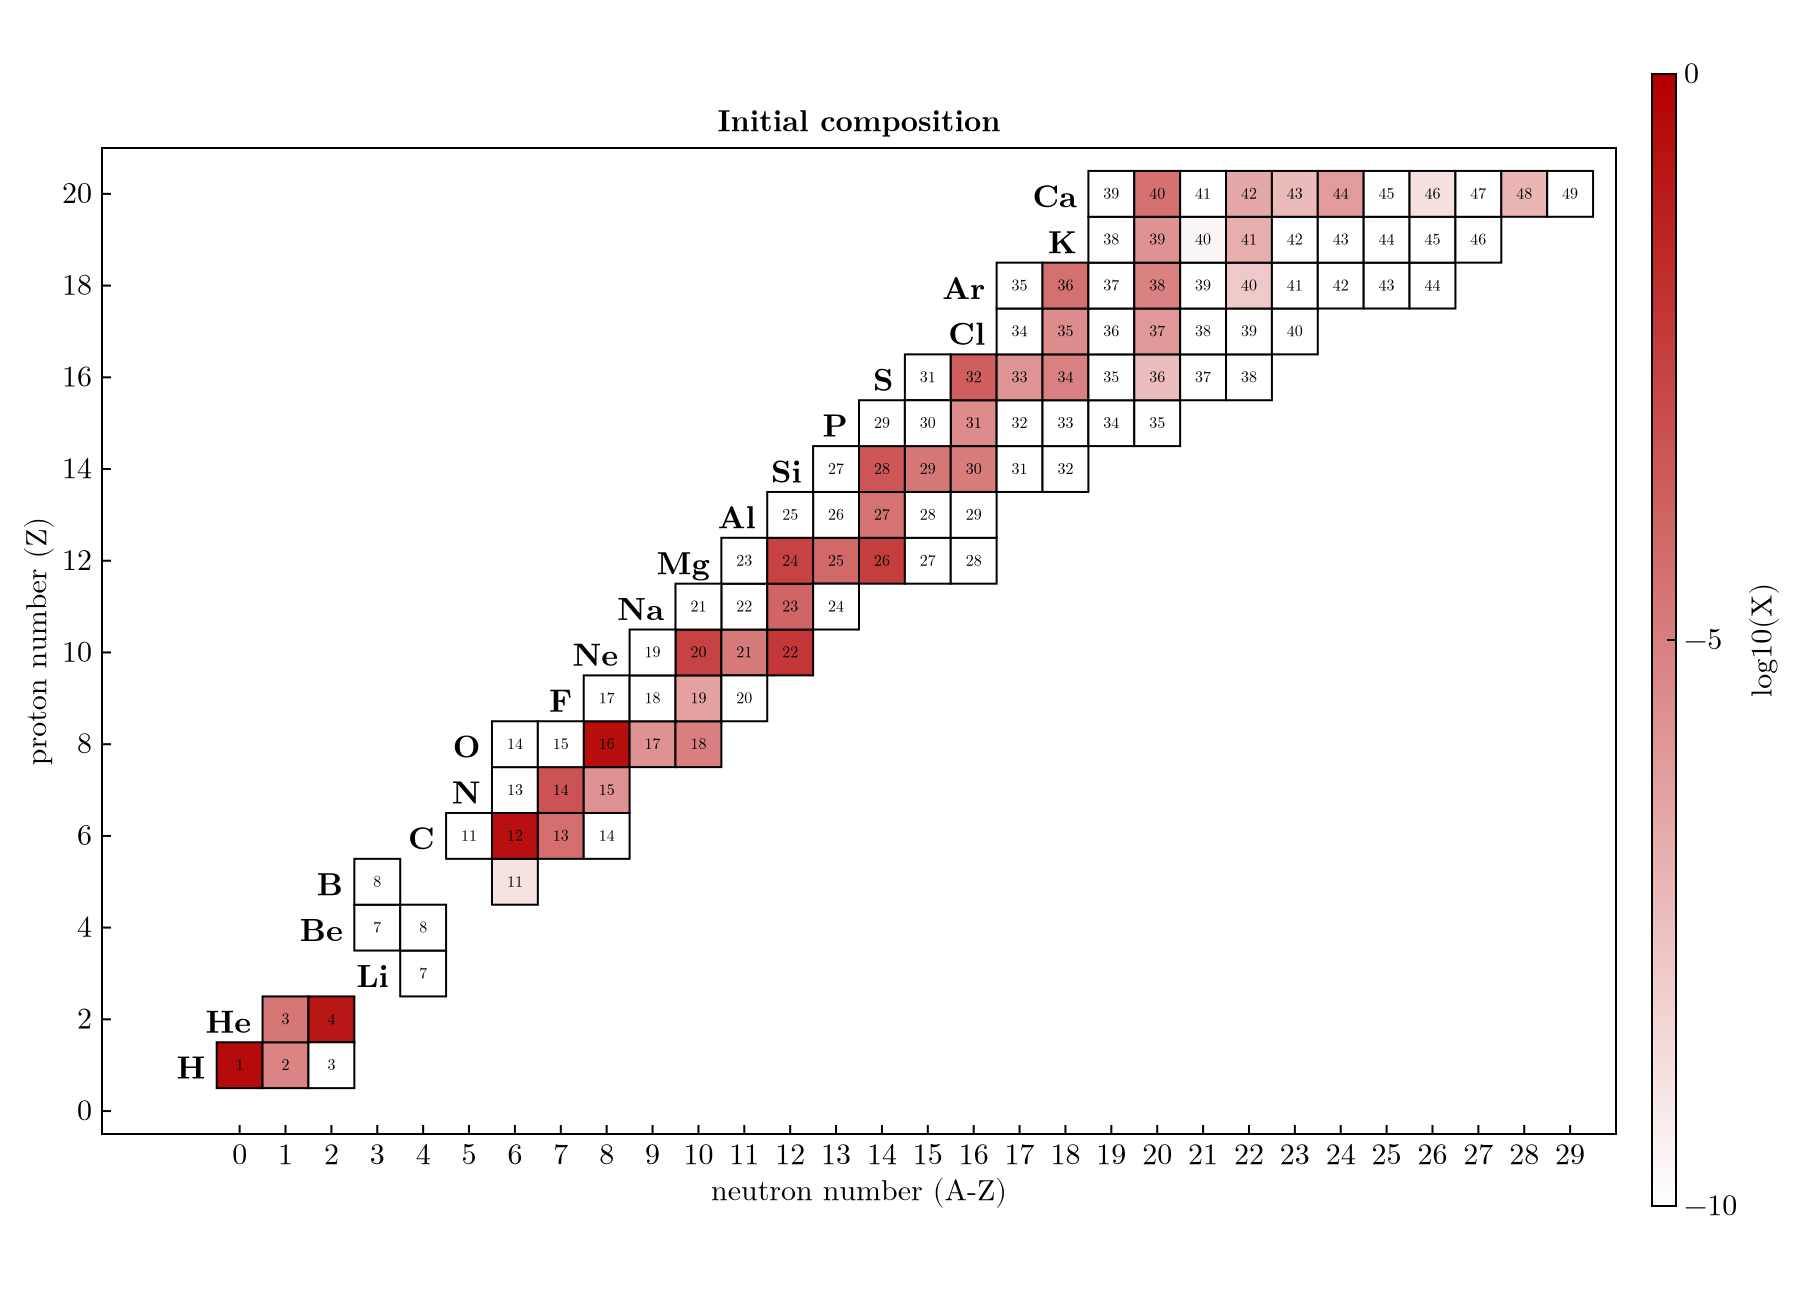

In [2]:
abundance_chart(run, :initial; title = "Initial composition")

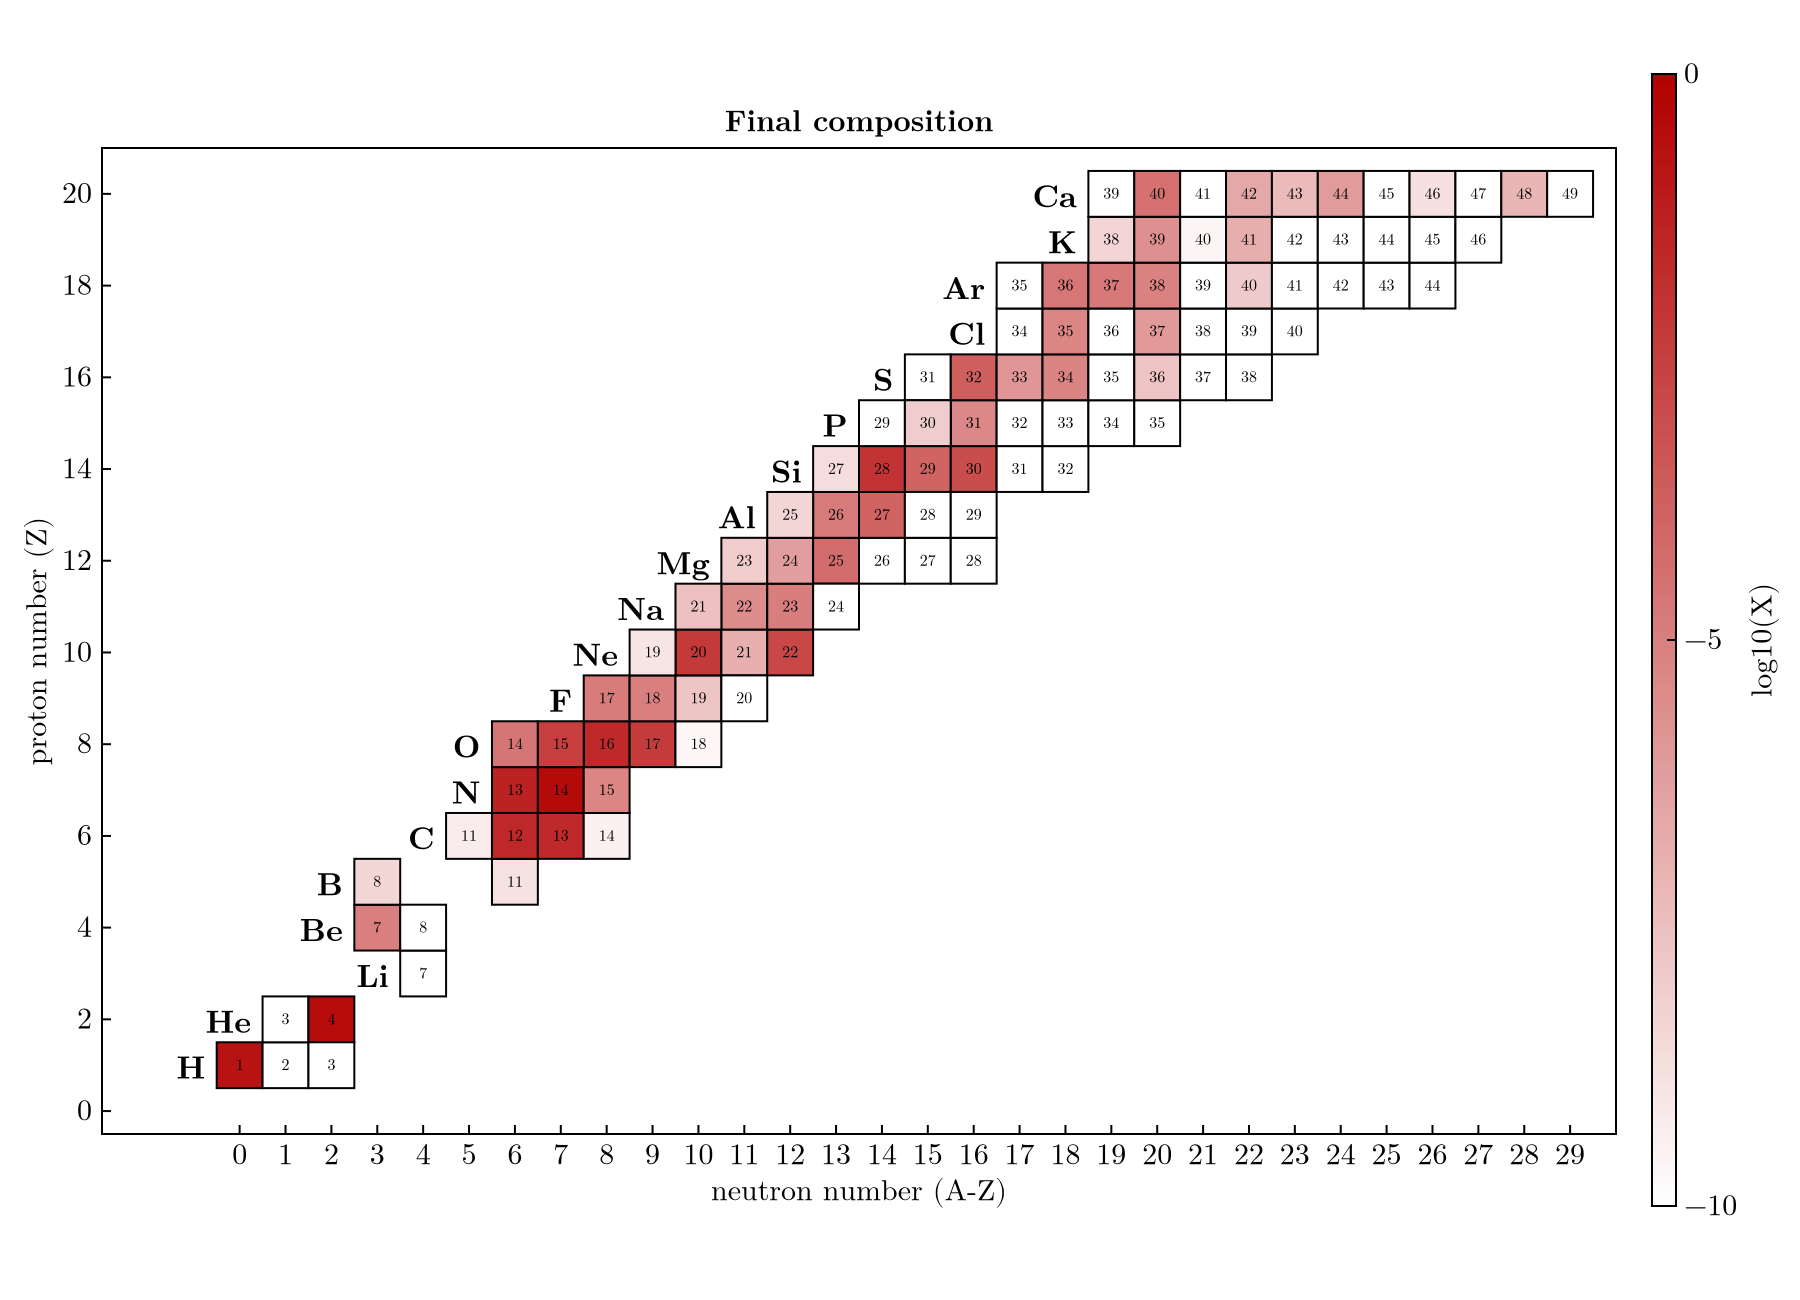

In [3]:
abundance_chart(run, :final; title = "Final composition")

You can also pass an already-loaded `Abundances` directly — useful once
you're comparing several runs and don't want to re-resolve a `PPNRun` each
time.

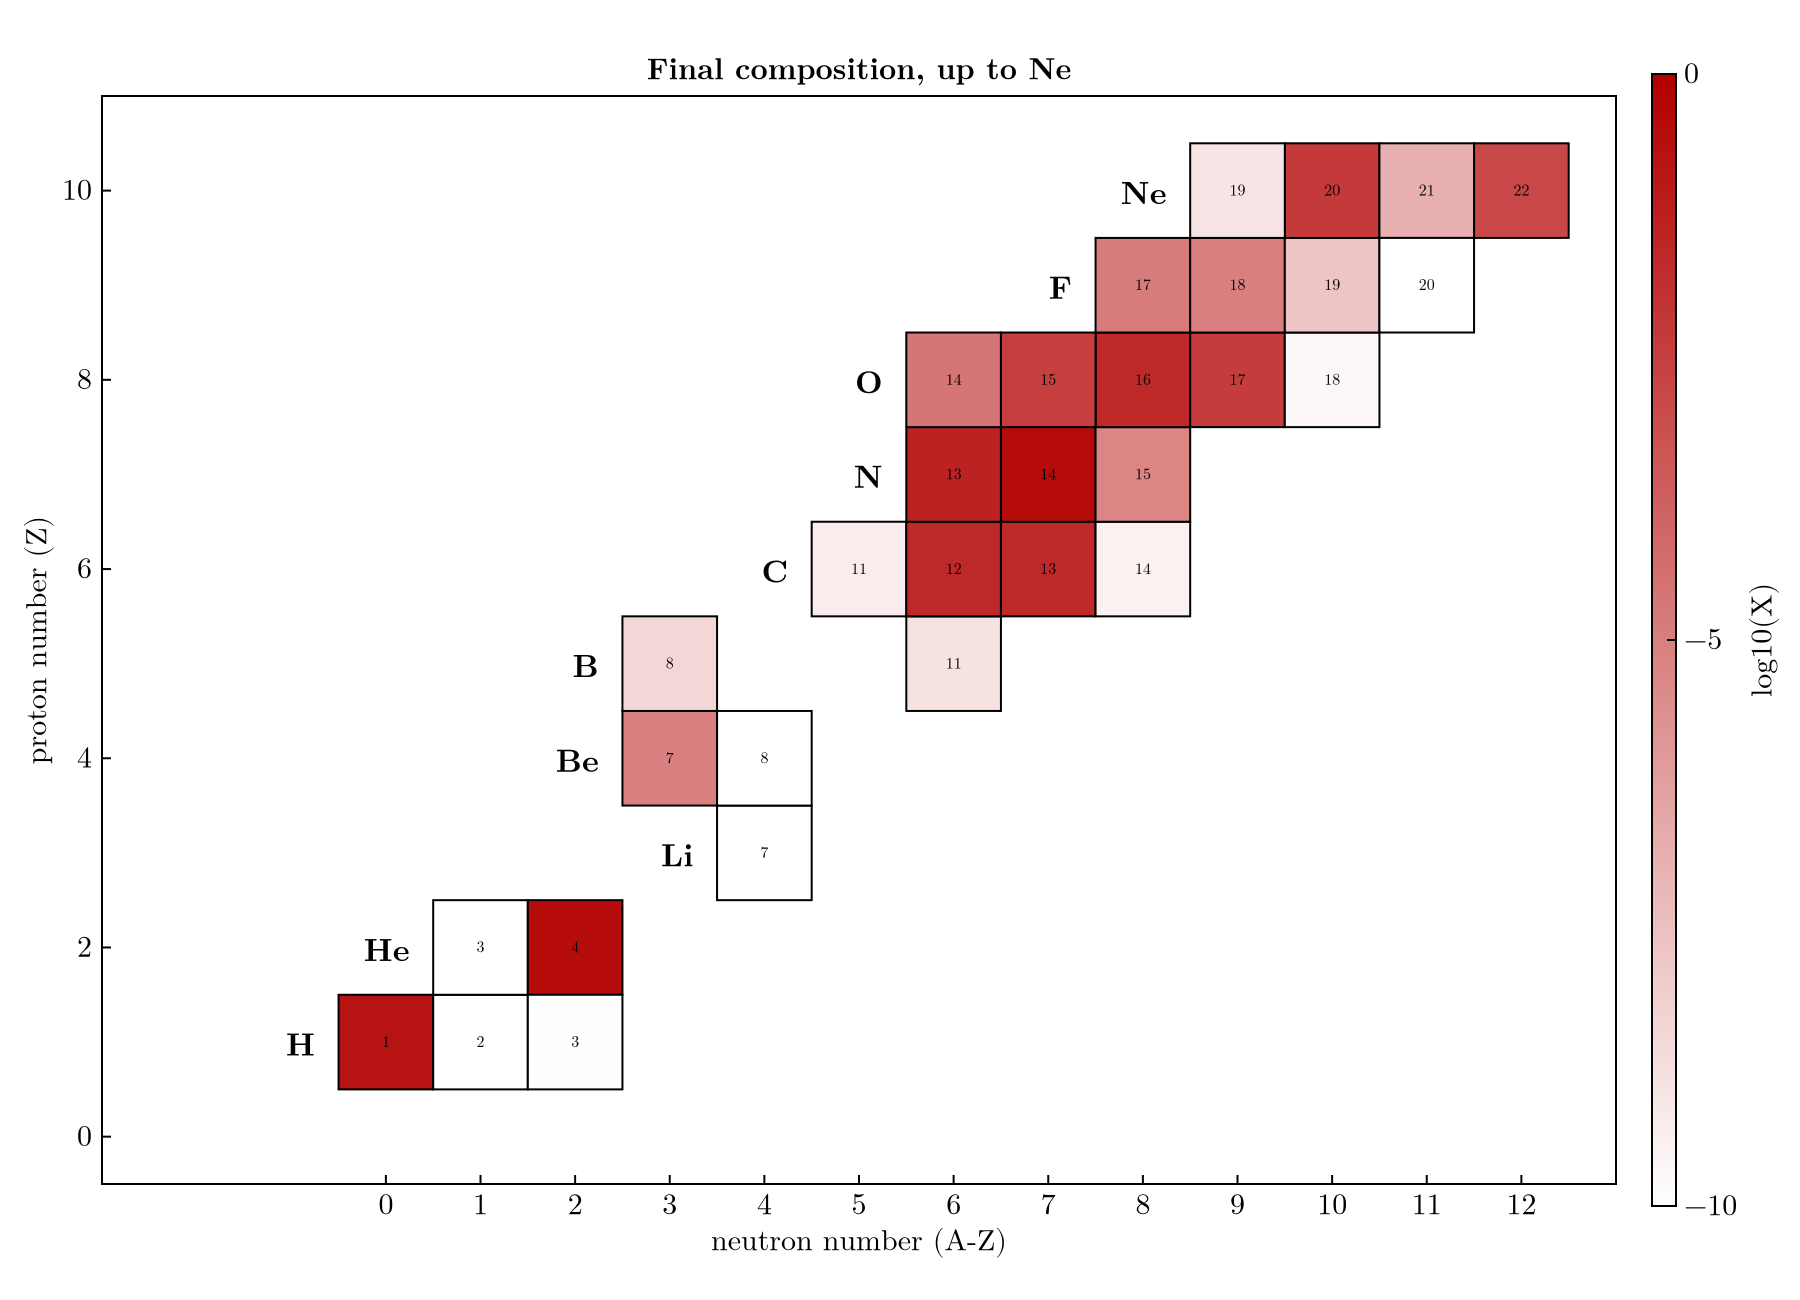

In [4]:
ab_final = abundances(run, :final)
abundance_chart(ab_final; element_limit = "Ne", title = "Final composition, up to Ne")

## A blank tile always means "not tracked"

`tolerance` (and `flux_chart`'s `tolerance` threshold) is a *color* floor,
not a visibility cutoff. Every isotope the run actually tracks gets a tile
and a mass-number label, even when its abundance floors out below
`tolerance` — it just colors at the floor (indistinguishable from zero)
instead of disappearing. That's deliberate: a gap in the grid should always
mean "this isotope isn't part of the network," never "it's here but tiny."
Push `tolerance` absurdly high and the grid stays intact, just uncolored:

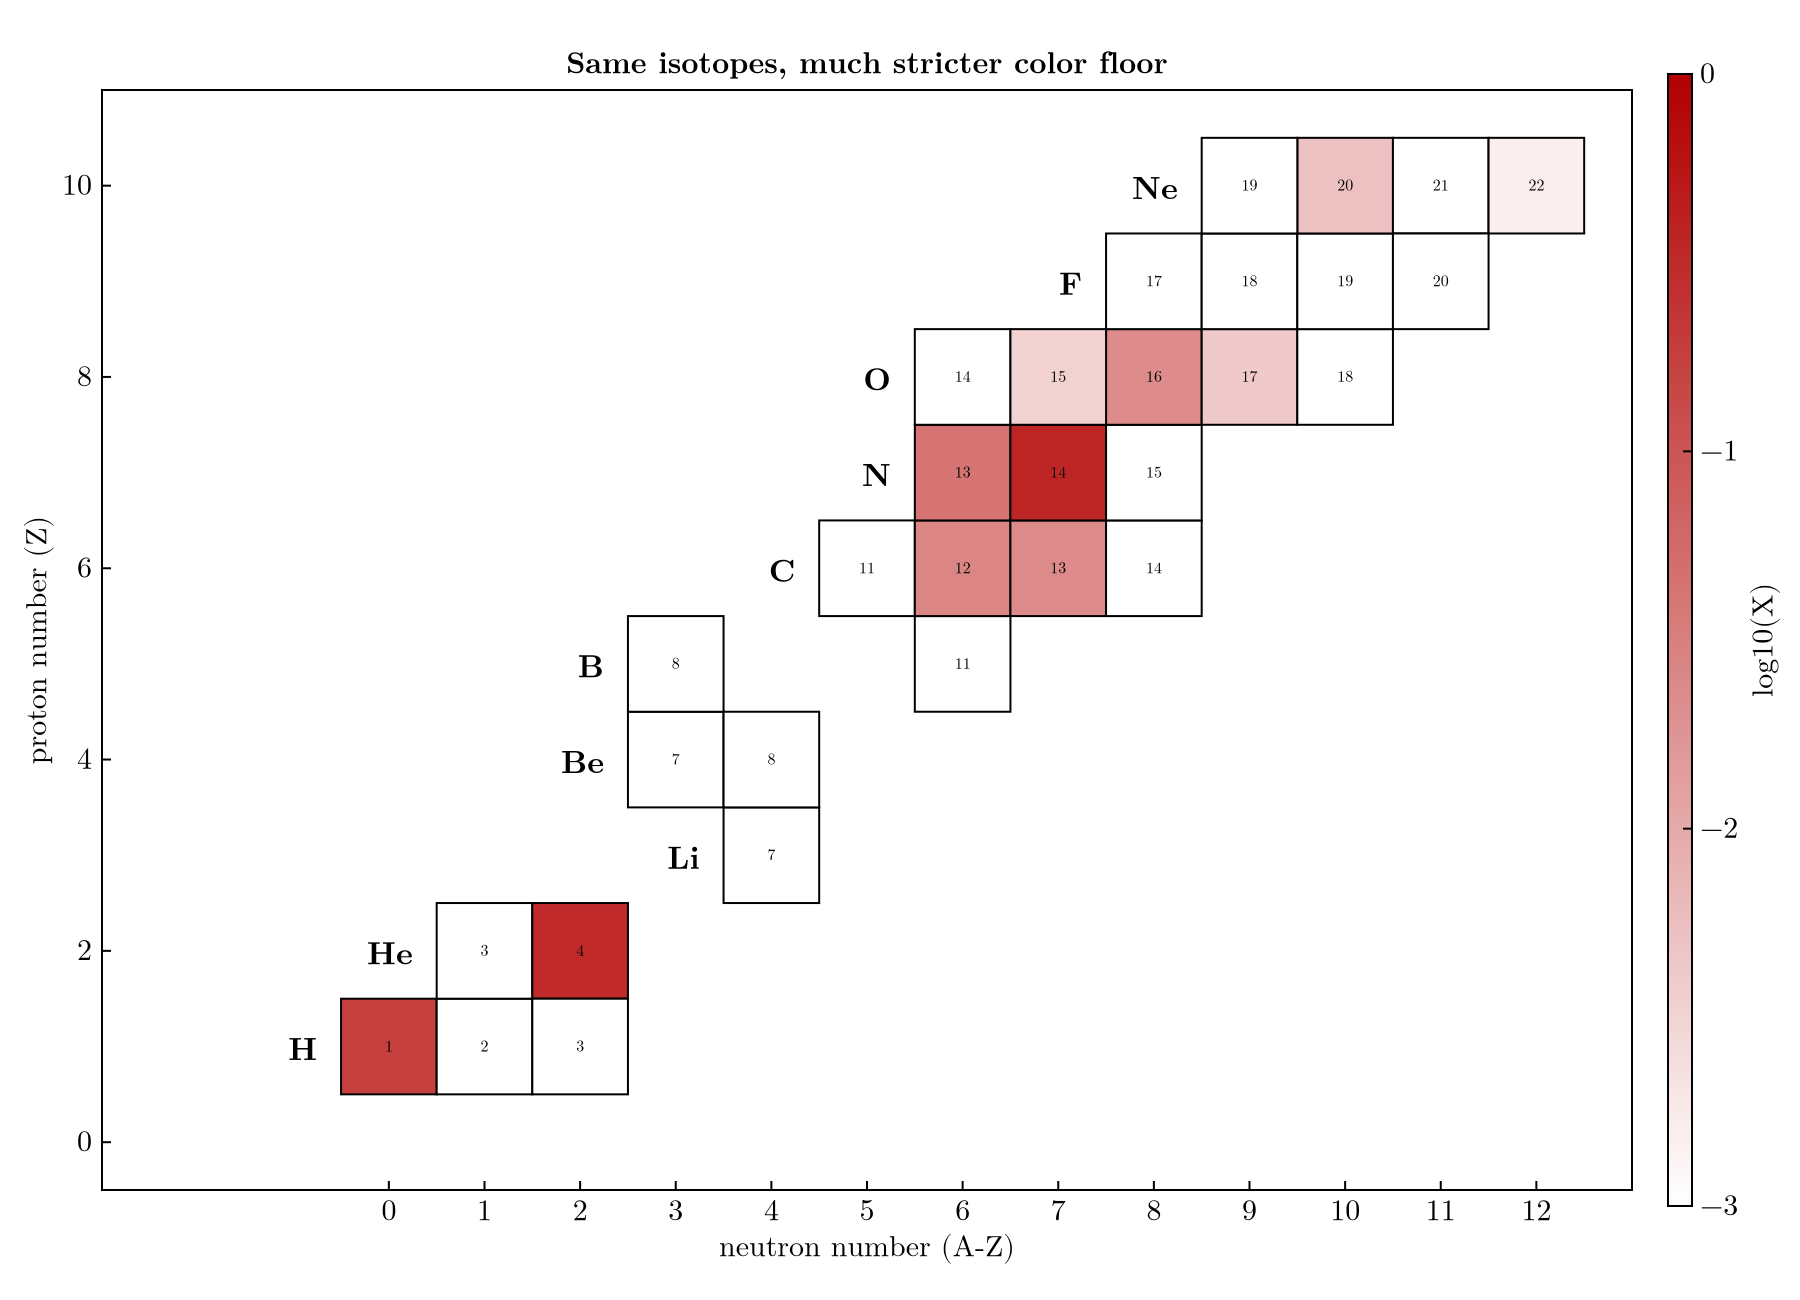

In [5]:
abundance_chart(run, :final; element_limit = "Ne", tolerance = 1e-3,
                 title = "Same isotopes, much stricter color floor")

## Flux chart

`flux_chart(run, cycle)` overlays reaction-flux arrows on the same grid,
with tiles colored by abundance by default (`show_abundance = true`) so flux
and abundance read together.

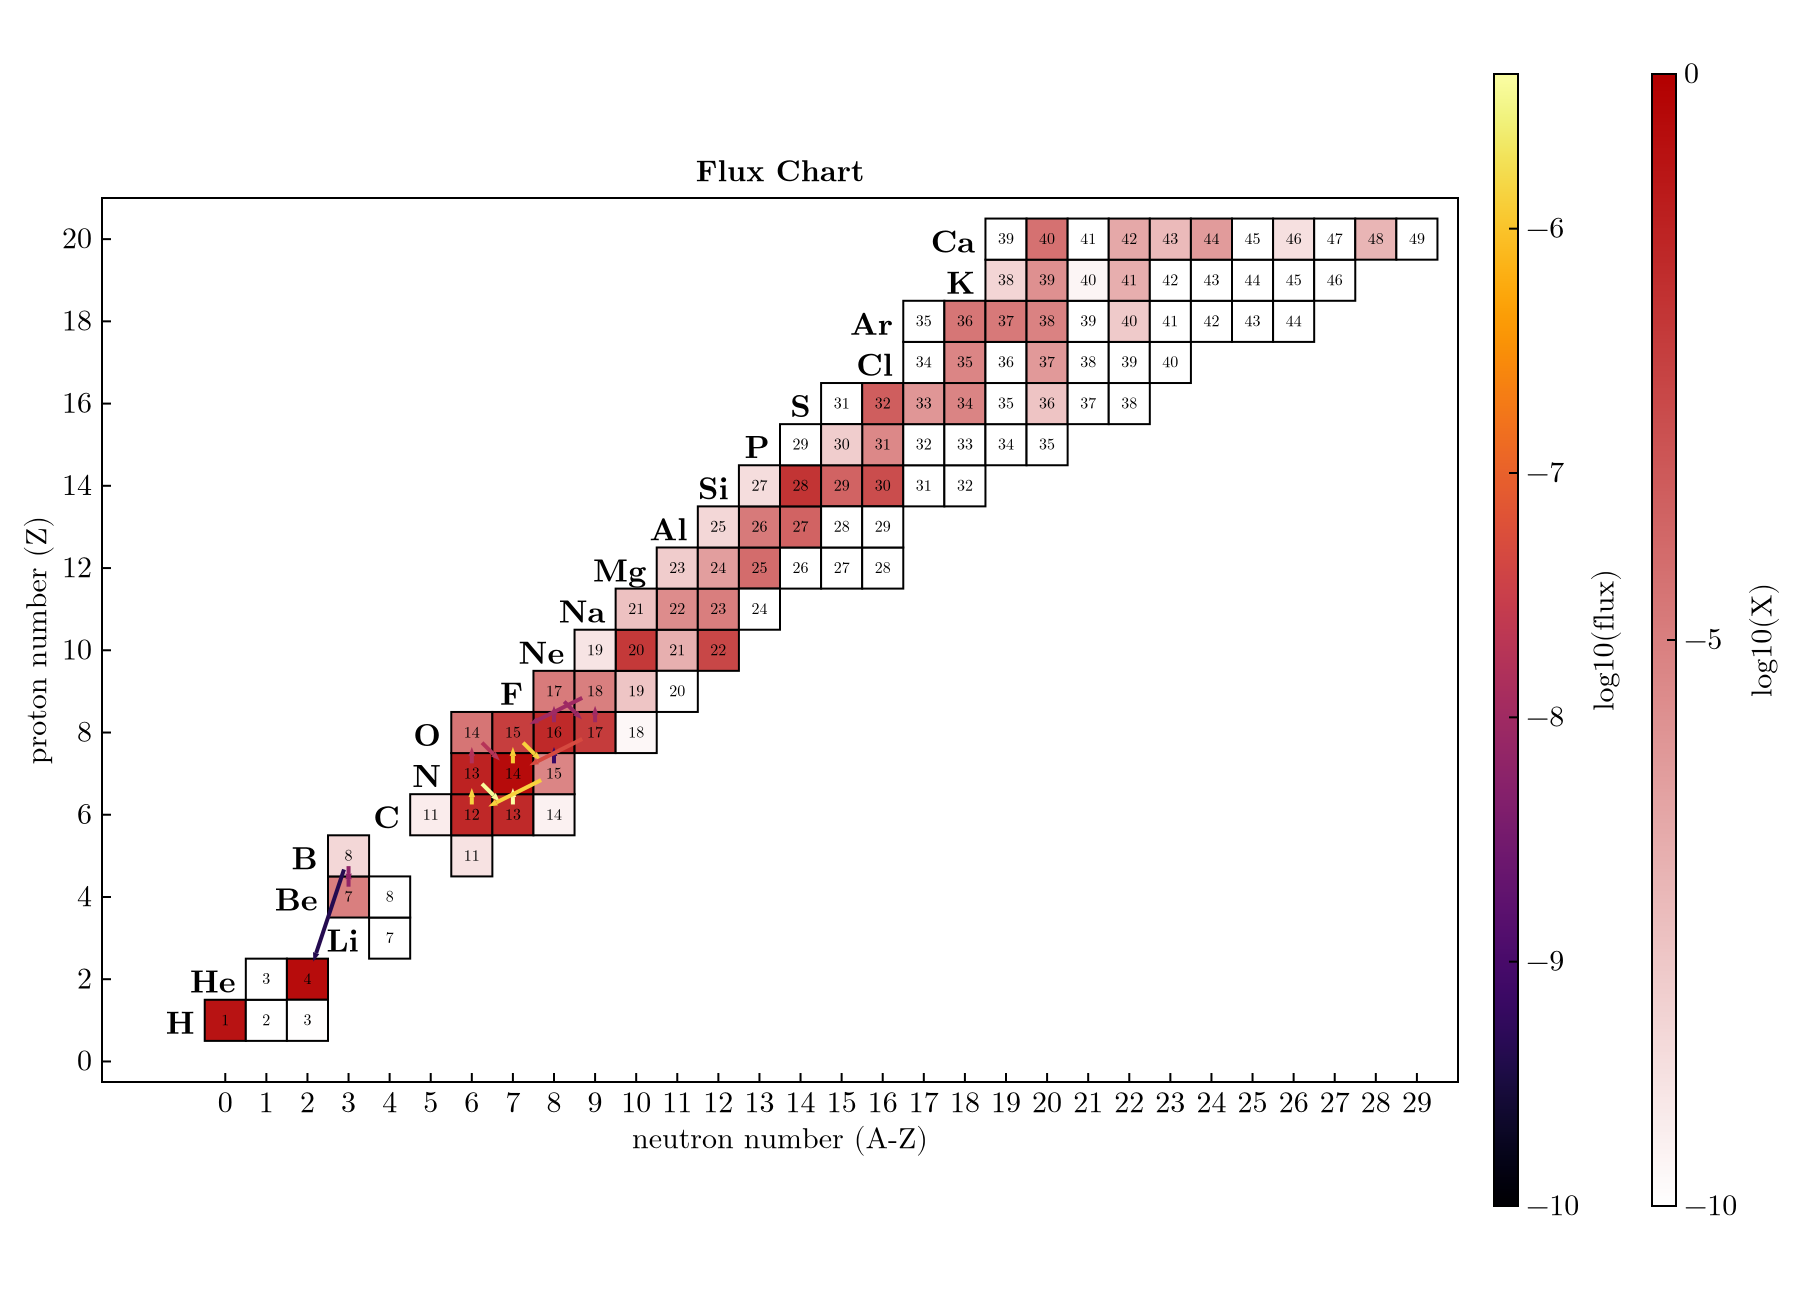

In [6]:
flux_chart(run, :final; tolerance = 1e-10)

Zoom to a region with `z_range`/`n_range`, or drop the abundance coloring
for a flux-only view:

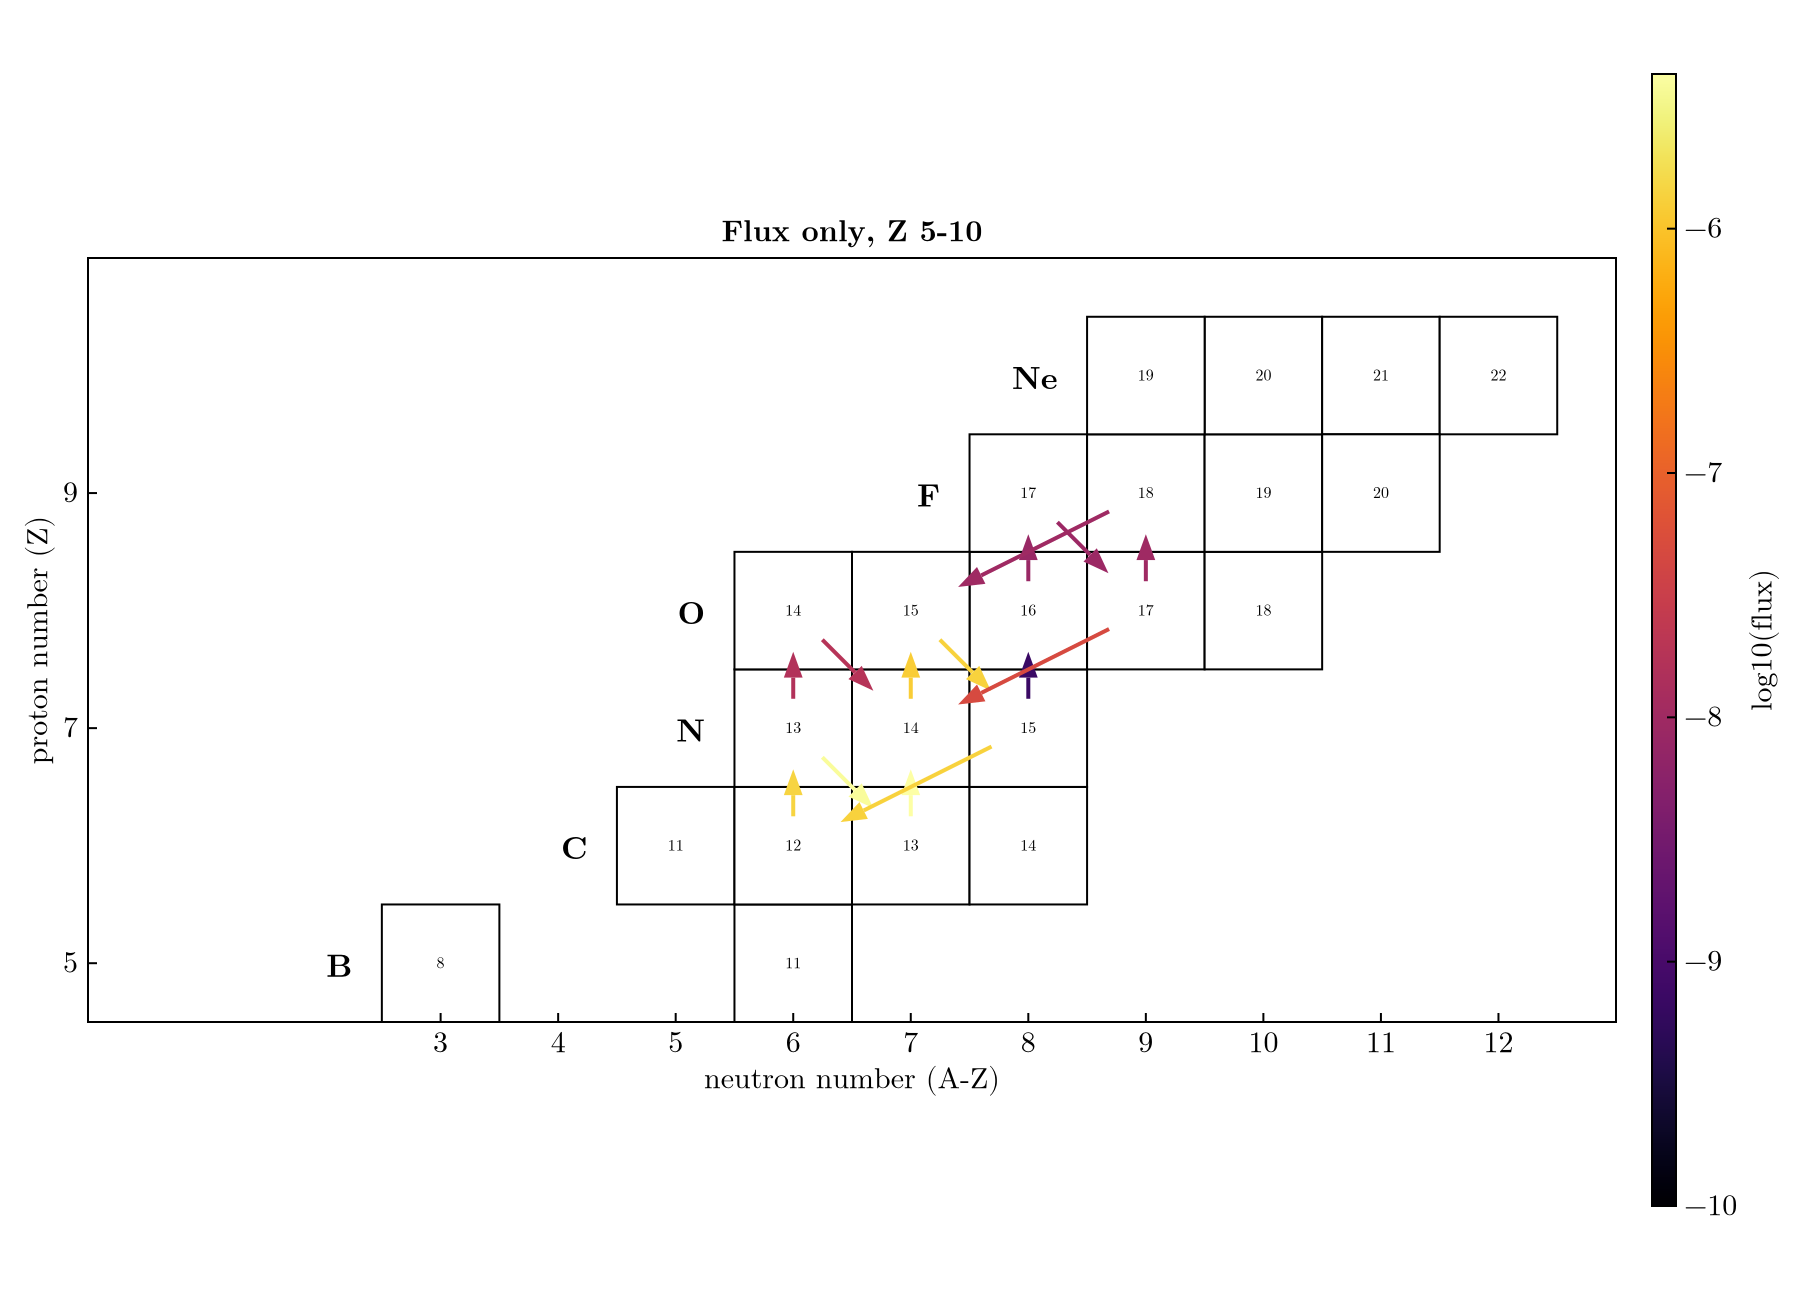

In [7]:
flux_chart(run, :final; tolerance = 1e-10, z_range = (5, 10), show_abundance = false,
           title = "Flux only, Z 5-10")

## The trajectory behind the run

These are charts of PPN's *output*. `plot_trajectory` instead plots the
*input* that drove it — `trajectory.input`'s time/T9/density history — via
`trajectory(run)` (notebook 1). `plot_density_temperature` is the same data
without the time axis, a quick check of how the burn actually evolved in
(T, ρ) space.

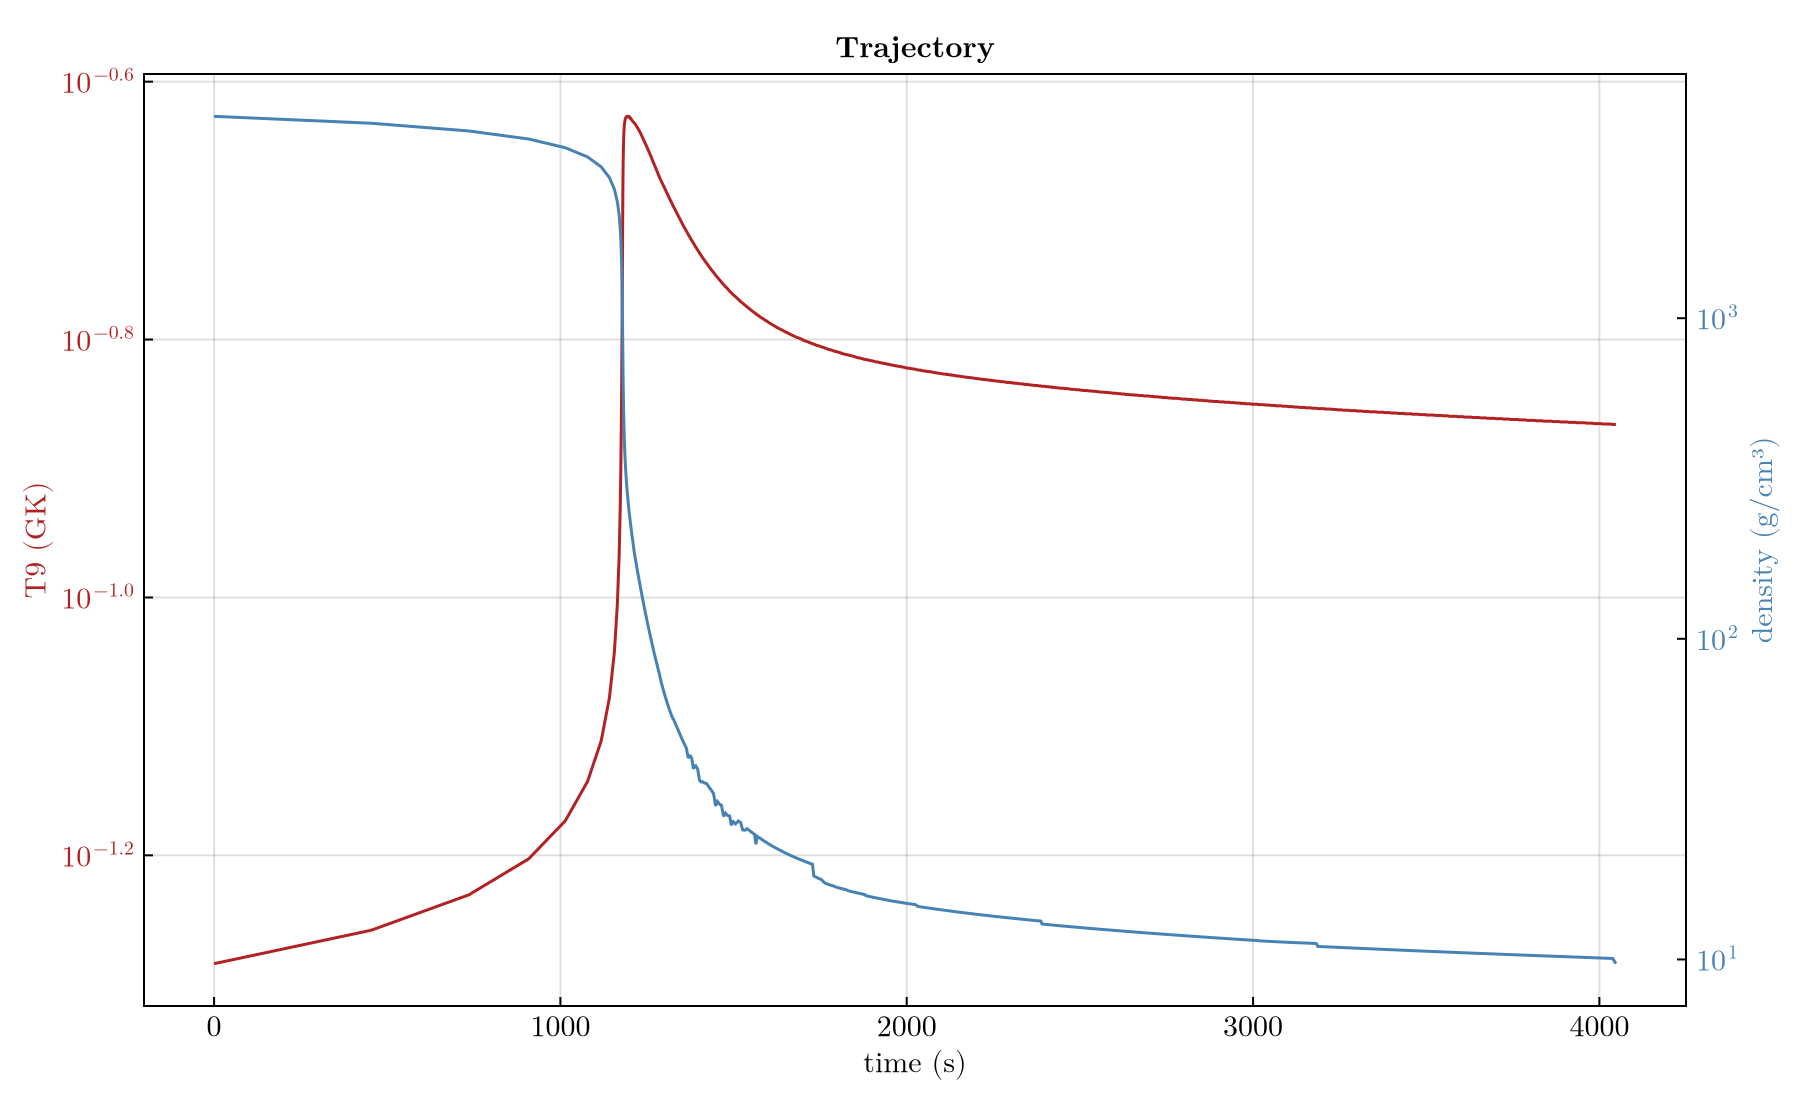

In [8]:
plot_trajectory(run)

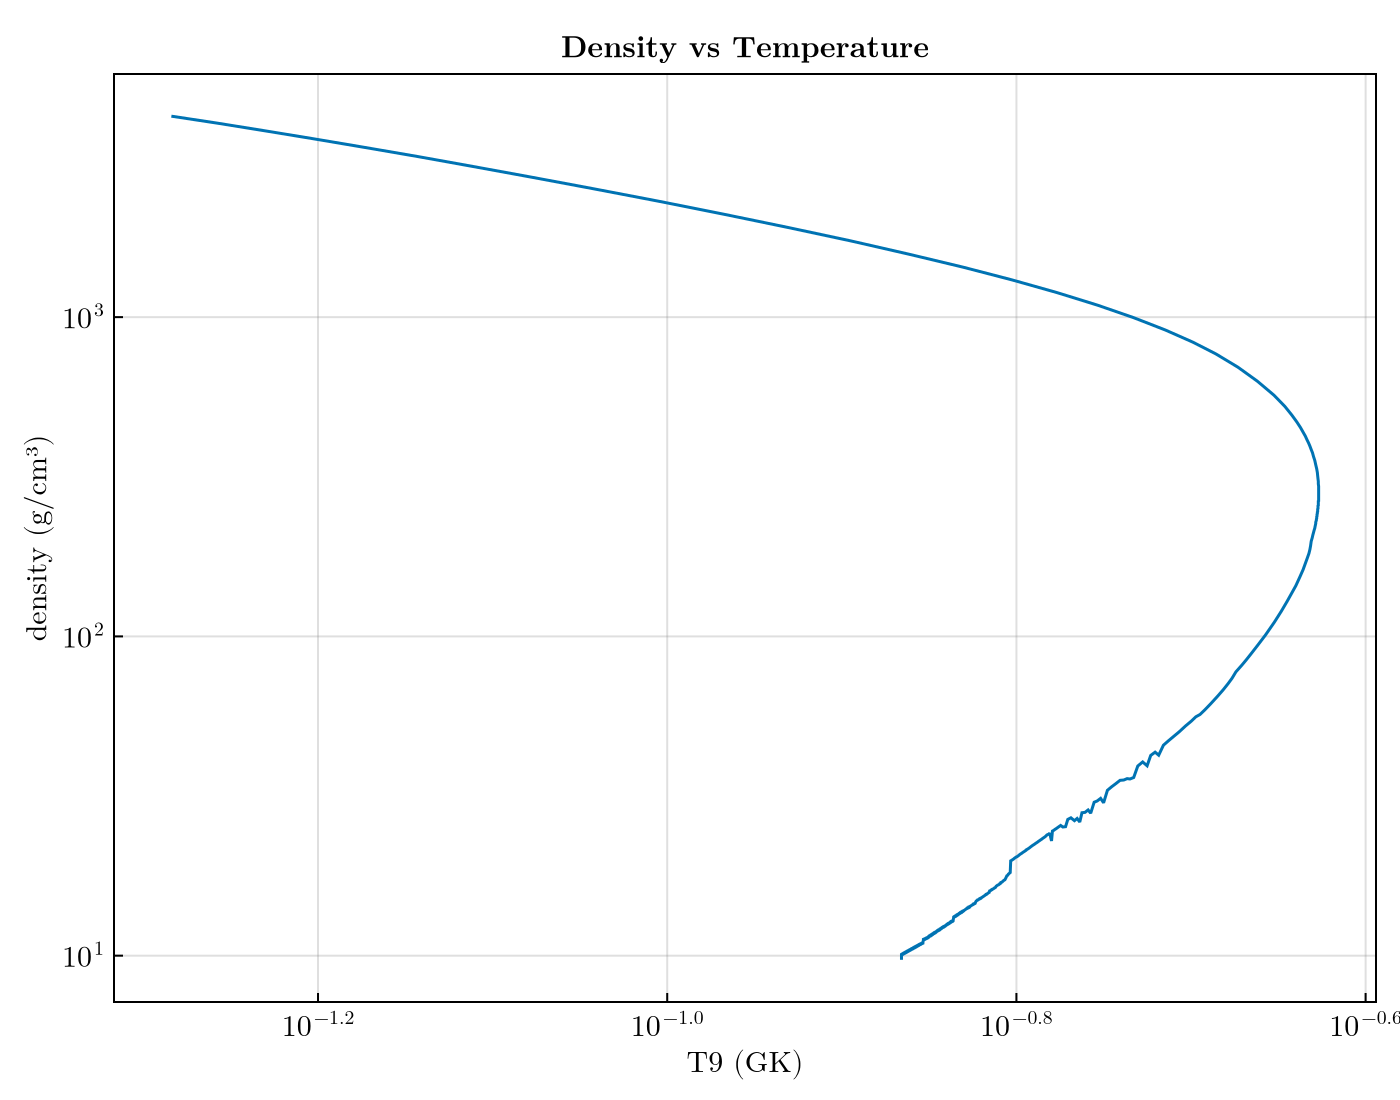

In [9]:
plot_density_temperature(run)

## Next

[`03_ratio_charts_and_time_evolution.ipynb`](03_ratio_charts_and_time_evolution.ipynb)
— compare two abundance sets and plot isotopes over time.